### **Libraries Import**

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

### **Data Load**

In [143]:
data = pd.read_csv("Dataset/financial_fraud_detection_&_risk_analytics.csv")

### **Data Structure**

In [144]:
data.head()

,Transaction_ID,Customer_ID,Merchant_ID,Transaction_Date,Amount,Payment_Method,Device_ID,IP_Address,Country,City,...,Currency,Merchant_Location,First_Name,Last_Name,Full_Name,Customer_Info,Notes,Raw_Status,Customer_Profile,Geo_Info
0,TXN0,60352,9861,10-09-2025,3461.5,crypto,DEV20325,90.142.246.222,UK,Berlin,...,USD,"Bangalore, India",David,Kumar,David Kumar,David|Kumar,Review needed,success,David~Kumar~user0@mail.com~3798466518.0,"Woodlands, Singapore"
1,TXN1,72892,9871,25-11-2025,5156.51,Card,DEV31347,176.203.2.144,India,Mumbai,...,USD,"Singapore, Singapore",Priya,Kumar,NaN,Priya|Kumar,NaN,PENDING,Priya~Kumar~user1@mail.com~9614339783.0,"Bristol, UK"
2,TXN2,81279,6133,12-03-2025,8542.27,Card,DEV48693,119.128.128.205,Singapore,Hamburg,...,AED,"Chennai, India",Anita,Taylor,Anita Taylor,Anita|Taylor,Review needed,PENDING,Anita~Taylor~user2@mail.com~2792518940.0,"Berlin, Germany"
3,TXN3,51536,4258,01-03-2024,2989.59,NetBanking,DEV27220,43.77.211.86,Singapore,Miami,...,AED,"Frankfurt, Germany",John,Patel,John Patel,John|Patel,NaN,SUCCESS,John~Patel~user3@mail.com~5379584840.0,"Tampines, Singapore"
4,TXN4,87041,7475,01-02-2024,2875.75,Card,DEV43684,161.20.47.72,USA,Hyderabad,...,USD,"Calgary, Canada",Michael,Sharma,Michael Sharma,Michael|Sharma,High risk,SUCCESS,Michael~Sharma~user4@mail.com~8006721385.0,"Birmingham, UK"


In [145]:
data.tail()

,Transaction_ID,Customer_ID,Merchant_ID,Transaction_Date,Amount,Payment_Method,Device_ID,IP_Address,Country,City,...,Currency,Merchant_Location,First_Name,Last_Name,Full_Name,Customer_Info,Notes,Raw_Status,Customer_Profile,Geo_Info
514995,TXN170853,57596,3355,11-03-2025,6327.25,crypto,DEV24085,249.124.216.164,UAE,Manchester,...,AED,"Chicago, USA",Priya,Sharma,Priya Sharma,Priya|Sharma,Fraud?,SUCCESS,Priya~Sharma~user170853@mail.com~7527921804.0,"Perth, Australia"
514996,TXN76680,90480,6214,06-02-2024,3175.98,NetBanking,DEV47651,229.136.239.70,UK,Edmonton,...,USD,"Hyderabad, India",Jane,Smith,NaN,Jane|Smith,Fraud?,PENDING,Jane~Smith~user76680@mail.com~5338168707.0,"Boston, USA"
514997,TXN375630,43853,7159,25-04-2025,10192.78,CARD,DEV25575,NaN,UAE,Bristol,...,USD,"Los Angeles, USA",Michael,Kumar,Michael Kumar,Michael|Kumar,ok,Failed,Michael~Kumar~user375630@mail.com~7415775948.0,"Cologne, Germany"
514998,TXN36657,11885,4715,29-12-2025,2479.74,CARD,DEV30626,119.61.18.130,India,Vancouver,...,USD,"Chennai, India",Sara,Brown,Sara Brown,Sara|Brown,ok,success,Sara~Brown~user36657@mail.com~5207876263.0,"Cologne, Germany"
514999,TXN405553,46296,1906,08-05-2024,2564.4,NetBanking,DEV22073,2.44.1.245,UAE,Bedok,...,USD,"Leeds, UK",Priya,Kumar,Priya Kumar,Priya|Kumar,Review needed,success,Priya~Kumar~user405553@mail.com~5688602653.0,"Canberra, Australia"


In [146]:
data.describe()

,Customer_ID,Merchant_ID,Account_Age,Transaction_Frequency,Chargeback_Flag,Fraud_Flag,Login_Attempts,Phone_Number
count,515000.000000,515000.000000,501859.000000,508089.000000,504624.000000,508226.000000,505989.000000,5.068420e+05
mean,55065.265509,5497.889664,2495.569885,249.527614,0.102084,0.060422,24.396916,5.498788e+09
std,25936.284413,2597.768643,1446.656137,144.178191,0.302759,0.238267,14.799969,2.599642e+09
min,10000.000000,1000.000000,-10.000000,0.000000,0.000000,0.000000,-50.000000,1.000018e+09
25%,32636.000000,3249.000000,1242.000000,125.000000,0.000000,0.000000,12.000000,3.245706e+09
50%,55074.000000,5500.000000,2495.000000,249.000000,0.000000,0.000000,25.000000,5.496270e+09
75%,77519.000000,7748.000000,3751.000000,374.000000,0.000000,0.000000,37.000000,7.758471e+09
max,99998.000000,9998.000000,4999.000000,499.000000,1.000000,1.000000,49.000000,9.999991e+09


In [147]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515000 entries, 0 to 514999
Data columns (total 32 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Transaction_ID         515000 non-null  object 
 1   Customer_ID            515000 non-null  int64  
 2   Merchant_ID            515000 non-null  int64  
 3   Transaction_Date       515000 non-null  object 
 4   Amount                 515000 non-null  object 
 5   Payment_Method         506804 non-null  object 
 6   Device_ID              504221 non-null  object 
 7   IP_Address             500576 non-null  object 
 8   Country                509451 non-null  object 
 9   City                   506979 non-null  object 
 10  Merchant_Category      502743 non-null  object 
 11  Account_Age            501859 non-null  float64
 12  Transaction_Frequency  508089 non-null  float64
 13  Chargeback_Flag        504624 non-null  float64
 14  Fraud_Flag             508226 non-nu

In [148]:
data.shape

(515000, 32)

# **Data Cleaning & Preprocessing**

### **Data Quality**

In [149]:
data.isnull().sum()
nullv = {}
for ds in data.columns:
    nullv[ds] = data[ds].isnull().sum()

nullv = pd.DataFrame({
    "Column": data.columns,
    "Null_Count": data.isnull().sum().values
})

nullv

,Column,Null_Count
0,Transaction_ID,0
1,Customer_ID,0
2,Merchant_ID,0
3,Transaction_Date,0
4,Amount,0
5,Payment_Method,8196
6,Device_ID,10779
7,IP_Address,14424
8,Country,5549
9,City,8021


In [150]:
data.duplicated().sum()

np.int64(0)

### **Remove Duplicates**

In [151]:
data.drop_duplicates(inplace=True)
data.shape

(515000, 32)

### **Split Column**

In [152]:
data[["cinfo_f_name","cinfo_l_name"]] = data["Customer_Info"].str.split("|",expand=True)
data[["cprofile_f_name","cprofile_l_name","cprofile_email","cprofile_mono"]] = data["Customer_Profile"].str.split("~",expand=True)
data[["geo_City","geo_Country"]] = data["Geo_Info"].str.split(", ",expand=True)
data

,Transaction_ID,Customer_ID,Merchant_ID,Transaction_Date,Amount,Payment_Method,Device_ID,IP_Address,Country,City,...,Customer_Profile,Geo_Info,cinfo_f_name,cinfo_l_name,cprofile_f_name,cprofile_l_name,cprofile_email,cprofile_mono,geo_City,geo_Country
0,TXN0,60352,9861,10-09-2025,3461.5,crypto,DEV20325,90.142.246.222,UK,Berlin,...,David~Kumar~user0@mail.com~3798466518.0,"Woodlands, Singapore",David,Kumar,David,Kumar,user0@mail.com,3798466518.0,Woodlands,Singapore
1,TXN1,72892,9871,25-11-2025,5156.51,Card,DEV31347,176.203.2.144,India,Mumbai,...,Priya~Kumar~user1@mail.com~9614339783.0,"Bristol, UK",Priya,Kumar,Priya,Kumar,user1@mail.com,9614339783.0,Bristol,UK
2,TXN2,81279,6133,12-03-2025,8542.27,Card,DEV48693,119.128.128.205,Singapore,Hamburg,...,Anita~Taylor~user2@mail.com~2792518940.0,"Berlin, Germany",Anita,Taylor,Anita,Taylor,user2@mail.com,2792518940.0,Berlin,Germany
3,TXN3,51536,4258,01-03-2024,2989.59,NetBanking,DEV27220,43.77.211.86,Singapore,Miami,...,John~Patel~user3@mail.com~5379584840.0,"Tampines, Singapore",John,Patel,John,Patel,user3@mail.com,5379584840.0,Tampines,Singapore
4,TXN4,87041,7475,01-02-2024,2875.75,Card,DEV43684,161.20.47.72,USA,Hyderabad,...,Michael~Sharma~user4@mail.com~8006721385.0,"Birmingham, UK",Michael,Sharma,Michael,Sharma,user4@mail.com,8006721385.0,Birmingham,UK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514995,TXN170853,57596,3355,11-03-2025,6327.25,crypto,DEV24085,249.124.216.164,UAE,Manchester,...,Priya~Sharma~user170853@mail.com~7527921804.0,"Perth, Australia",Priya,Sharma,Priya,Sharma,user170853@mail.com,7527921804.0,Perth,Australia
514996,TXN76680,90480,6214,06-02-2024,3175.98,NetBanking,DEV47651,229.136.239.70,UK,Edmonton,...,Jane~Smith~user76680@mail.com~5338168707.0,"Boston, USA",Jane,Smith,Jane,Smith,user76680@mail.com,5338168707.0,Boston,USA
514997,TXN375630,43853,7159,25-04-2025,10192.78,CARD,DEV25575,NaN,UAE,Bristol,...,Michael~Kumar~user375630@mail.com~7415775948.0,"Cologne, Germany",Michael,Kumar,Michael,Kumar,user375630@mail.com,7415775948.0,Cologne,Germany
514998,TXN36657,11885,4715,29-12-2025,2479.74,CARD,DEV30626,119.61.18.130,India,Vancouver,...,Sara~Brown~user36657@mail.com~5207876263.0,"Cologne, Germany",Sara,Brown,Sara,Brown,user36657@mail.com,5207876263.0,Cologne,Germany


### **Standardize Text Values**

In [153]:
data["Payment_Method"] = data["Payment_Method"].str.lower().replace({
      "netbanking" : "NetBanking",
      "card" : "Card",
      "crypto" : "Crypto",
      "cash" : "Cash",
      "upi" : "UPI",
})

data["Country"] = data["Country"].str.lower().replace({
      "india" : "India",
      "usa" : "USA",
      "uk" : "UK",
      "uae" : "UAE",
      "singapore" : "Singapore",
      "canada" : "Canada",
      "australia" : "Australia",
      "germany" : "Germany",
})

data["City"] = data["City"].str.title().str.strip()
data["Merchant_Category"] = data["Merchant_Category"].str.title().str.strip()
data["Device_Type"] = data["Device_Type"].str.title().str.strip()
data["KYC_Status"] = data["KYC_Status"].str.title().str.strip()
data["Customer_Segment"] = data["Customer_Segment"].str.title().str.strip()
data["Email"] = data["Email"].str.lower().str.strip()
data["First_Name"] = data["First_Name"].str.title().str.strip()
data["Last_Name"] = data["Last_Name"].str.title().str.strip()
data["Full_Name"] = data["Full_Name"].str.title().str.strip()
data["Raw_Status"] = data["Raw_Status"].str.title().str.strip()

for clm in data.columns.to_list():
      if data[clm].dtype == "object":
            data[clm] = data[clm].str.strip()

### **Fix Data Type**

In [154]:
data["Transaction_Date"] = pd.to_datetime(data["Transaction_Date"], format='mixed', dayfirst=True, errors='coerce')

data["Amount"] = pd.to_numeric(data["Amount"], errors='coerce')

data["Transaction_ID"] = data["Transaction_ID"].astype(object)
data["Customer_ID"] = data["Customer_ID"].astype(object)
data["Merchant_ID"] = data["Merchant_ID"].astype(object)
data["Payment_Method"] = data["Payment_Method"].astype(object)
data["Device_ID"] = data["Device_ID"].astype(object)
data["IP_Address"] = data["IP_Address"].astype(object)
data["Country"] = data["Country"].astype(object)
data["City"] = data["City"].astype(object)
data["Merchant_Category"] = data["Merchant_Category"].astype(object)
data["Device_Type"] = data["Device_Type"].astype(object)
data["KYC_Status"] = data["KYC_Status"].astype(object)
data["Customer_Segment"] = data["Customer_Segment"].astype(object)
data["Email"] = data["Email"].astype(object)
data["Phone_Number"] = data["Phone_Number"].astype(object)
data["Currency"] = data["Currency"].astype(object)
data["First_Name"] = data["First_Name"].astype(object)
data["Last_Name"] = data["Last_Name"].astype(object)
data["Full_Name"] = data["Full_Name"].astype(object)
data["Notes"] = data["Notes"].astype(object)
data["Raw_Status"] = data["Raw_Status"].astype(object)

data["Account_Age"] = pd.to_numeric(data["Account_Age"], errors='coerce').astype("Int64")
data["Transaction_Frequency"] = pd.to_numeric(data["Transaction_Frequency"], errors='coerce').astype("Int64")
data["Chargeback_Flag"] = pd.to_numeric(data["Chargeback_Flag"], errors='coerce').astype("Int64")
data["Fraud_Flag"] = pd.to_numeric(data["Fraud_Flag"], errors='coerce').astype("Int64")
data["Risk_Score"] = pd.to_numeric(data["Risk_Score"], errors='coerce').astype("Int64")
data["Login_Attempts"] = pd.to_numeric(data["Login_Attempts"], errors='coerce').astype("Int64")

In [155]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515000 entries, 0 to 514999
Data columns (total 40 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Transaction_ID         515000 non-null  object        
 1   Customer_ID            515000 non-null  object        
 2   Merchant_ID            515000 non-null  object        
 3   Transaction_Date       513475 non-null  datetime64[ns]
 4   Amount                 511950 non-null  float64       
 5   Payment_Method         506804 non-null  object        
 6   Device_ID              504221 non-null  object        
 7   IP_Address             500576 non-null  object        
 8   Country                509451 non-null  object        
 9   City                   506979 non-null  object        
 10  Merchant_Category      502743 non-null  object        
 11  Account_Age            501859 non-null  Int64         
 12  Transaction_Frequency  508089 non-null  Int6

### **Handle Missing Values**

In [156]:
country_city_map = {
    "India": ["Mumbai", "Delhi", "Bangalore", "Ahmedabad", "Hyderabad", "Chennai", "Pune"],
    "USA": ["New York", "Los Angeles", "Chicago", "Houston", "San Francisco", "Miami", "Seattle", "Boston"],
    "UK": ["London", "Manchester", "Birmingham","Liverpool", "Leeds", "Bristol"],
    "UAE": ["Dubai", "Abu Dhabi", "Sharjah","Ajman", "Al Ain"],
    "Singapore": ["Singapore", "Tampines", "Jurong East","Woodlands", "Bedok"],
    "Canada": ["Toronto", "Vancouver", "Montreal","Calgary", "Ottawa", "Edmonton"],
    "Australia": ["Sydney", "Melbourne", "Brisbane","Perth", "Adelaide", "Canberra"],
    "Germany": ["Berlin", "Munich", "Hamburg","Frankfurt", "Cologne"]
}

merchant_segment_count = data.groupby("Merchant_Category")["Customer_Segment"].agg(lambda x: x.value_counts().index[0])
segment_merchant_count = data.groupby("Customer_Segment")["Merchant_Category"].agg(lambda x: x.value_counts().index[0])

merchant_segment_count, segment_merchant_count

(Merchant_Category
 Food         Corporate
 Gaming          Retail
 Insurance    Corporate
 Retail          Retail
 Travel         Premium
 Name: Customer_Segment, dtype: object,
 Customer_Segment
 Corporate         Food
 Premium      Insurance
 Retail          Gaming
 Name: Merchant_Category, dtype: object)

In [157]:
data["Device_ID"] = data["Device_ID"].fillna(
    data.groupby("IP_Address")["Device_ID"].transform("first")
)
data["IP_Address"] = data["IP_Address"].fillna(
    data.groupby("Device_ID")["IP_Address"].transform("first")
)

data["Merchant_Category"] = data["Merchant_Category"].fillna(data["Customer_Segment"])
data["Customer_Segment"] = data["Customer_Segment"].fillna(data["Merchant_Category"])

data.fillna({
      "Country" : data["geo_Country"],
      "City" : data["geo_City"],
      "Merchant_Location" : f"{data['City'], data['Country']}",
      "First_Name" : data["cinfo_f_name"],
      "Last_Name" : data["cprofile_l_name"],
      "Full_Name" : f"{data['First_Name']} {data['Full_Name']}",
}, inplace=True)

data["Currency"] = np.select(
    [
        data["Country"] == "India",
        data["Country"] == "USA",
        data["Country"] == "UK",
        data["Country"] == "UAE",
        data["Country"] == "Singapore",
        data["Country"] == "Canada",
        data["Country"] == "Australia",
        data["Country"] == "Germany"
    ],
    [
        "INR",
        "USD",
        "GBP",
        "AED",
        "SGD",
        "CAD",
        "AUD",
        "EUR"
    ],
    default="Unknown"
)

data["Device_Type"].fillna("Unknown", inplace=True)
data["Payment_Method"].fillna("Unknown", inplace=True)
data["Notes"].fillna("N/A")

C:\Users\Krishnam Mavani\AppData\Local\Temp\ipykernel_1456\4209258088.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Device_Type"].fillna("Unknown", inplace=True)
C:\Users\Krishnam Mavani\AppData\Local\Temp\ipykernel_1456\4209258088.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

0         Review needed
1                   N/A
2         Review needed
3                   N/A
4             High risk
              ...      
514995           Fraud?
514996           Fraud?
514997               ok
514998               ok
514999    Review needed
Name: Notes, Length: 515000, dtype: object

### **Handle Outliers**

In [158]:
data["Amount_Zscore"] = stats.zscore(data["Amount"].astype(float), nan_policy='omit')
amount_outlier = data[data["Amount_Zscore"].abs() > 3]

data["Risk_Score_Zscore"] = stats.zscore(data["Risk_Score"].astype(float), nan_policy='omit')
data["Transaction_Frequency_Zscore"] = stats.zscore(data["Transaction_Frequency"].astype(float), nan_policy='omit')

In [159]:
data.loc[data["Account_Age"] < 0, "Account_Age"] = np.nan
data["Account_Age"] = data["Account_Age"].fillna(data["Account_Age"].median())

data["Transaction_Frequency"] = data["Transaction_Frequency"].fillna(
      data.groupby("Customer_Segment")["Transaction_Frequency"].transform("median")
)

data["Chargeback_Flag"] = data["Chargeback_Flag"].fillna(
      data.groupby("Chargeback_Flag")["Fraud_Flag"].agg(lambda x: x.mode().iloc[0])
)

data["Fraud_Flag"] = data["Fraud_Flag"].fillna(
      data.groupby("Fraud_Flag")["Risk_Score"].agg(lambda x: x.mode().iloc[0])
)

data["Risk_Score"] = data["Risk_Score"].fillna(data[["Fraud_Flag","Chargeback_Flag"]].median())

data["Login_Attempts"] = data["Login_Attempts"].fillna(
      data.groupby("Login_Attempts")["Fraud_Flag"].transform("median")
)

### **Drop Unvalid Columns**

In [160]:
data.head(3)

,Transaction_ID,Customer_ID,Merchant_ID,Transaction_Date,Amount,Payment_Method,Device_ID,IP_Address,Country,City,...,cinfo_l_name,cprofile_f_name,cprofile_l_name,cprofile_email,cprofile_mono,geo_City,geo_Country,Amount_Zscore,Risk_Score_Zscore,Transaction_Frequency_Zscore
0,TXN0,60352,9861,2025-09-10,3461.50,Crypto,DEV20325,90.142.246.222,UK,Berlin,...,Kumar,David,Kumar,user0@mail.com,3798466518.0,Woodlands,Singapore,-0.063403,1.396076,0.946555
1,TXN1,72892,9871,2025-11-25,5156.51,Card,DEV31347,176.203.2.144,India,Mumbai,...,Kumar,Priya,Kumar,user1@mail.com,9614339783.0,Bristol,UK,-0.063133,-1.518623,0.502659
2,TXN2,81279,6133,2025-03-12,8542.27,Card,DEV48693,119.128.128.205,Singapore,Hamburg,...,Taylor,Anita,Taylor,user2@mail.com,2792518940.0,Berlin,Germany,-0.062595,-0.825618,-0.634824


##### **Drop Remains Null Values Rows From Dataset**

In [161]:
data.drop(["cinfo_f_name","cinfo_l_name","cprofile_f_name","cprofile_l_name","cprofile_email","cprofile_mono","geo_City","geo_Country"], axis=1, inplace=True)
data.drop(["Customer_Info", "Merchant_Location", "Customer_Profile","Geo_Info"], axis=1, inplace=True)
# data.drop(amount_outlier, index=1)

##### **Drop Unused Column For Data Visualization**

In [162]:
data.drop(["Email","Phone_Number"], axis=1, inplace=True)

### **Export Clean Dataset**

In [163]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515000 entries, 0 to 514999
Data columns (total 29 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Transaction_ID                515000 non-null  object        
 1   Customer_ID                   515000 non-null  object        
 2   Merchant_ID                   515000 non-null  object        
 3   Transaction_Date              513475 non-null  datetime64[ns]
 4   Amount                        511950 non-null  float64       
 5   Payment_Method                515000 non-null  object        
 6   Device_ID                     504567 non-null  object        
 7   IP_Address                    514706 non-null  object        
 8   Country                       515000 non-null  object        
 9   City                          515000 non-null  object        
 10  Merchant_Category             514725 non-null  object        
 11  Account_Age  

In [164]:
data.to_csv("Dataset/cleaned.csv", index=False)

# **Data Visualization**

#### **1. Fraud vs Non-Fraud Transactions**

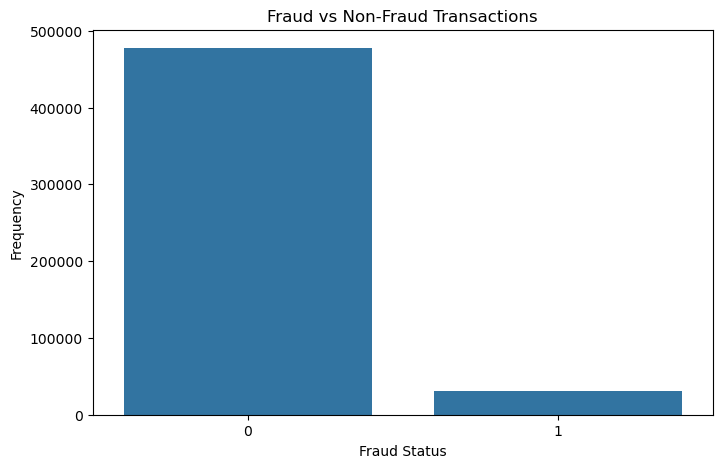

In [195]:
plt.figure(figsize=(8,5))
sns.countplot(data=data,x="Fraud_Flag")
plt.xlabel("Fraud Status")
plt.ylabel("Frequency")
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

#### **2. Transaction Amount Distribution**

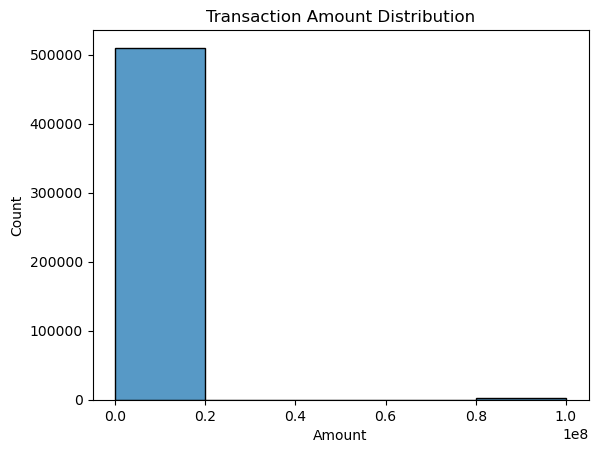

In [199]:
sns.histplot(data["Amount"], bins=5)
plt.title("Transaction Amount Distribution")
plt.show()

#### **3. Risk Score Distribution**

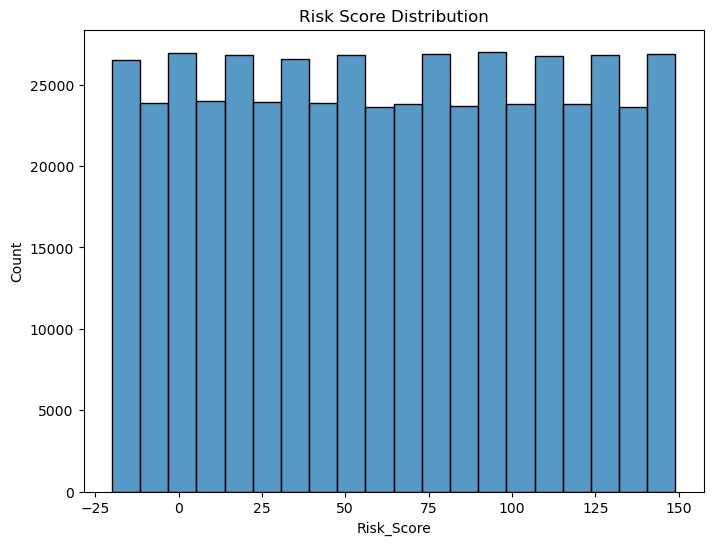

In [203]:
plt.figure(figsize=(8,6))
sns.histplot(data["Risk_Score"], bins=20)
plt.title("Risk Score Distribution")
plt.show()

#### **4. Fraud by Payment Method**

In [214]:
paymentmethod_dist = data["Payment_Method"].value_counts().reset_index()
paymentmethod_dist.columns = ["Payment Method","Fraud Ratio"]
fig = px.pie(paymentmethod_dist, names="Payment Method", values="Fraud Ratio", title="Fraud Ratio by Payment Method")
fig.show()

#### **5. Fraud by Country**

In [240]:
fraud_country = (
      data.groupby("Country")["Fraud_Flag"]
      .sum()
      .reset_index()
)
fig = px.bar(fraud_country, x="Country", y="Fraud_Flag", title="Fraud Transactions by Country")
fig.show()

#### **6. Fraud by Merchant Category**

In [241]:
fraud_cat = (
      data.groupby("Merchant_Category")["Fraud_Flag"]
      .sum()
      .reset_index()
)
fig = px.treemap(fraud_cat, path=["Merchant_Category"], values="Fraud_Flag", title="Fraud by Merchant Category")
fig.show()

#### **7. Fraud Trend Over Time**

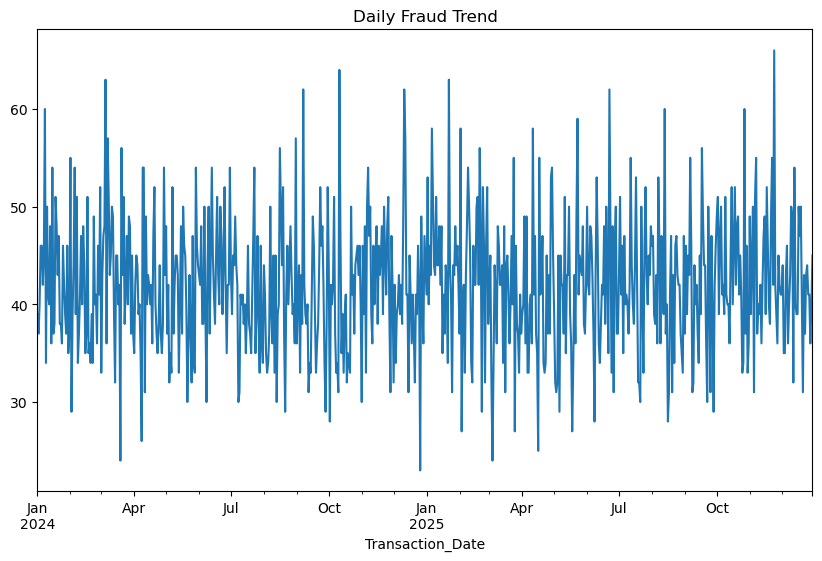

In [242]:
plt.figure(figsize=(10,6))
daily_fraud = (
      data.groupby("Transaction_Date")["Fraud_Flag"]
      .sum()
)
daily_fraud.plot()
plt.title("Daily Fraud Trend")
plt.show()

#### **8. Risk Score vs Amount**

In [233]:
per30data = int(data.shape[0] * 0.15)
fig = px.scatter(data.sample(per30data), x="Amount", y="Risk_Score", color="Fraud_Flag", title="Risk Score vs Amount")
fig.show()

#### **9. Amount Boxplot**

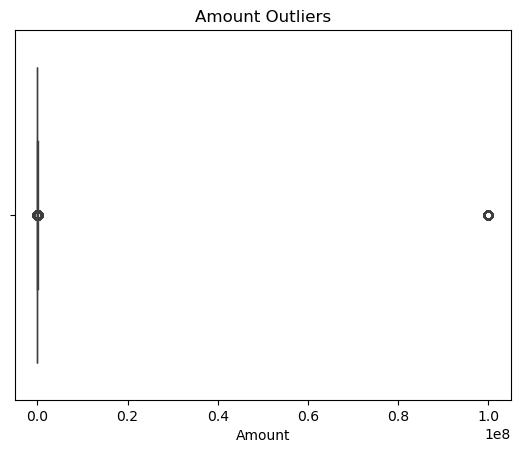

In [234]:
sns.boxplot(x=data["Amount"])
plt.title("Amount Outliers")
plt.show()

#### **10. Risk Score Boxplot by Fraud**

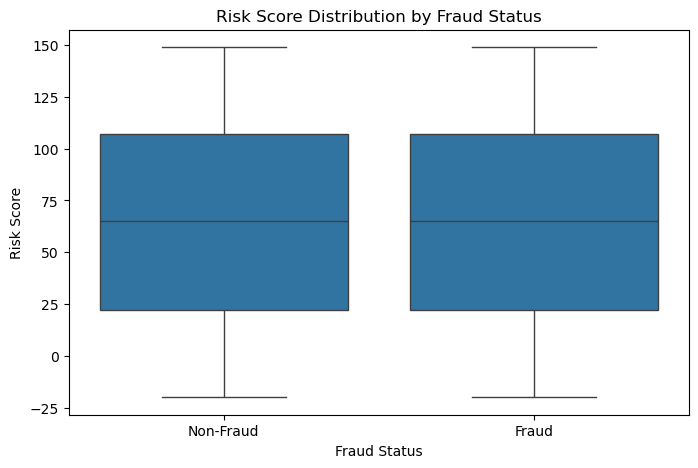

In [193]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    x="Fraud_Flag",
    y="Risk_Score"
)

plt.title("Risk Score Distribution by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Risk Score")

plt.xticks(
    [0, 1],
    ["Non-Fraud", "Fraud"]
)

plt.show()

#### **11. Correlation Heatmap**

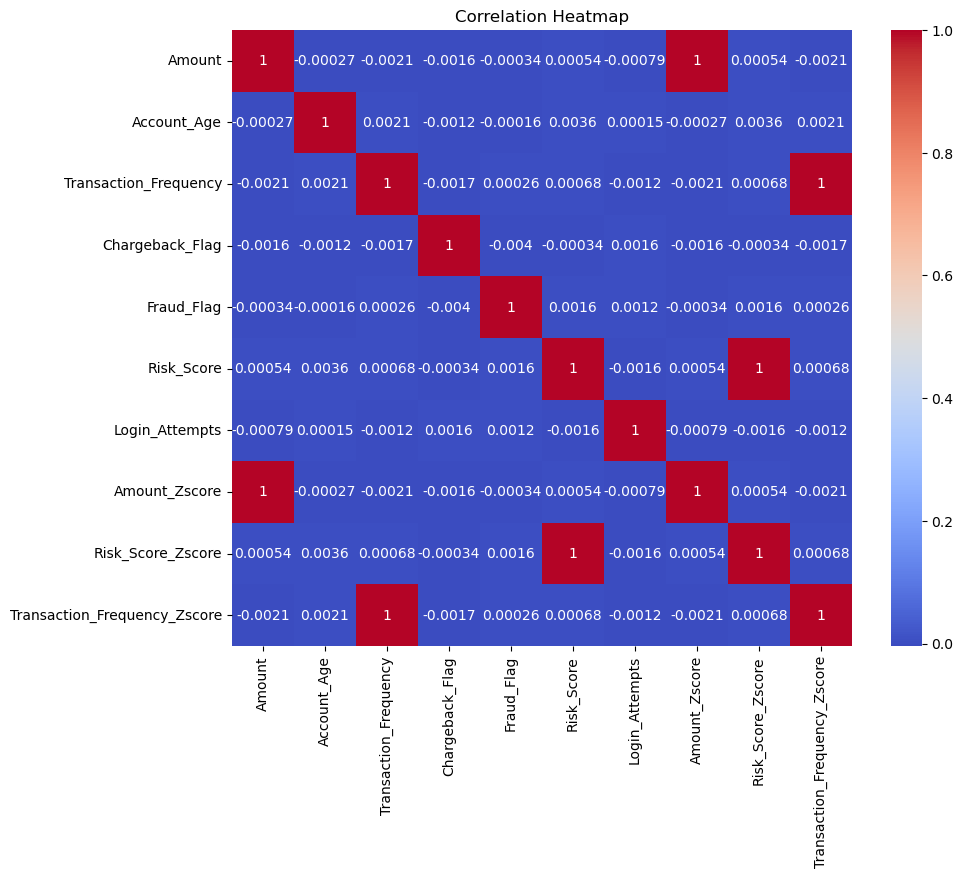

In [236]:
numeric_cols = data.select_dtypes(include=["int64","float64"])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### **12. Fraud by Device Type**

In [243]:
device = (
      data.groupby("Device_Type")["Fraud_Flag"]
      .sum()
      .reset_index()
)
fig = px.pie(device, names="Device_Type", values="Fraud_Flag", title="Fraud by Device Type")
fig.show()

#### **13. Top Suspicious Devices**

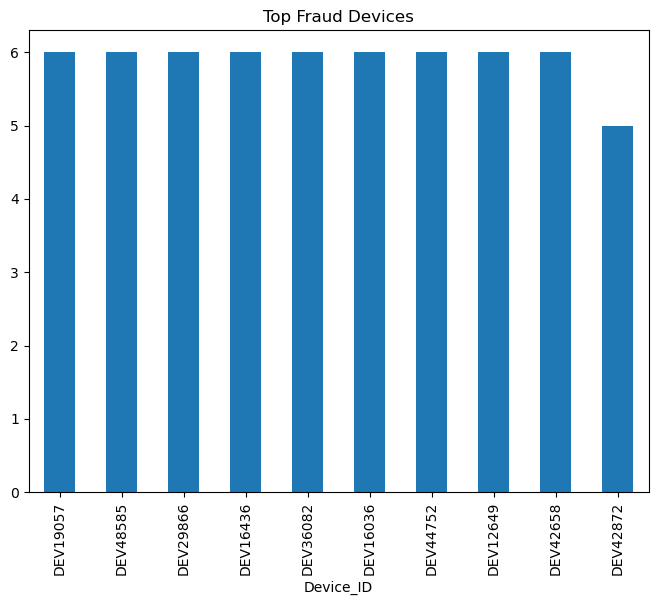

In [239]:
n = 10

plt.figure(figsize=(8,6))
suspicious_devices = (
    data.groupby("Device_ID")["Fraud_Flag"]
    .sum()
    .sort_values(ascending=False)
    .head(n)
)

suspicious_devices.plot(kind="bar")
plt.title("Top Fraud Devices")
plt.show()

#### **14. KYC Status Distribution**

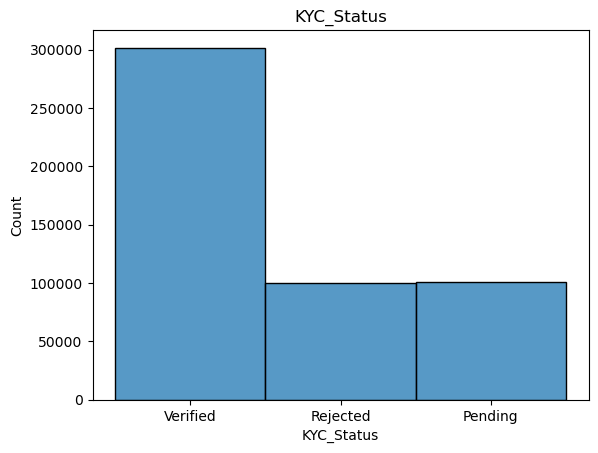

In [182]:
sns.histplot(data=data, x="KYC_Status")
plt.title("KYC_Status")
plt.show()

#### **15. Fraud by KYC Status**

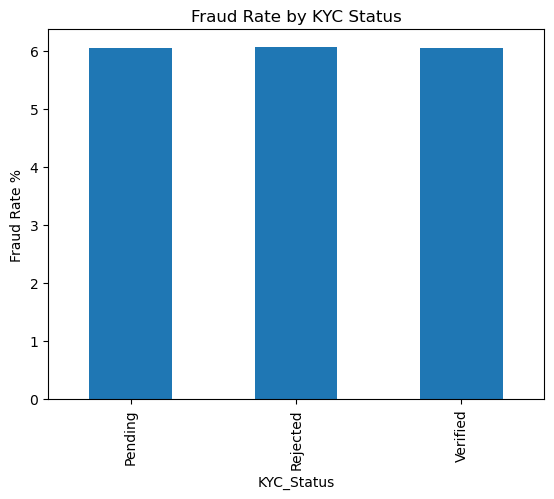

In [244]:
kyc = (
      data.groupby("KYC_Status")["Fraud_Flag"]
      .mean()*100
)
kyc.plot(kind="bar")
plt.ylabel("Fraud Rate %")
plt.title("Fraud Rate by KYC Status")
plt.show()

#### **16. Customer Segment Analysis**

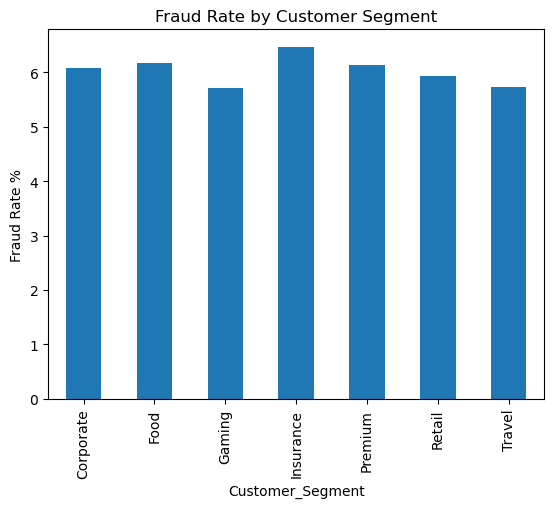

In [245]:
segment = (
      data.groupby("Customer_Segment")["Fraud_Flag"]
      .mean()*100
)
segment.plot(kind="bar")
plt.ylabel("Fraud Rate %")
plt.title("Fraud Rate by Customer Segment")
plt.show()

#### **17. Transaction Frequency vs Risk Score**

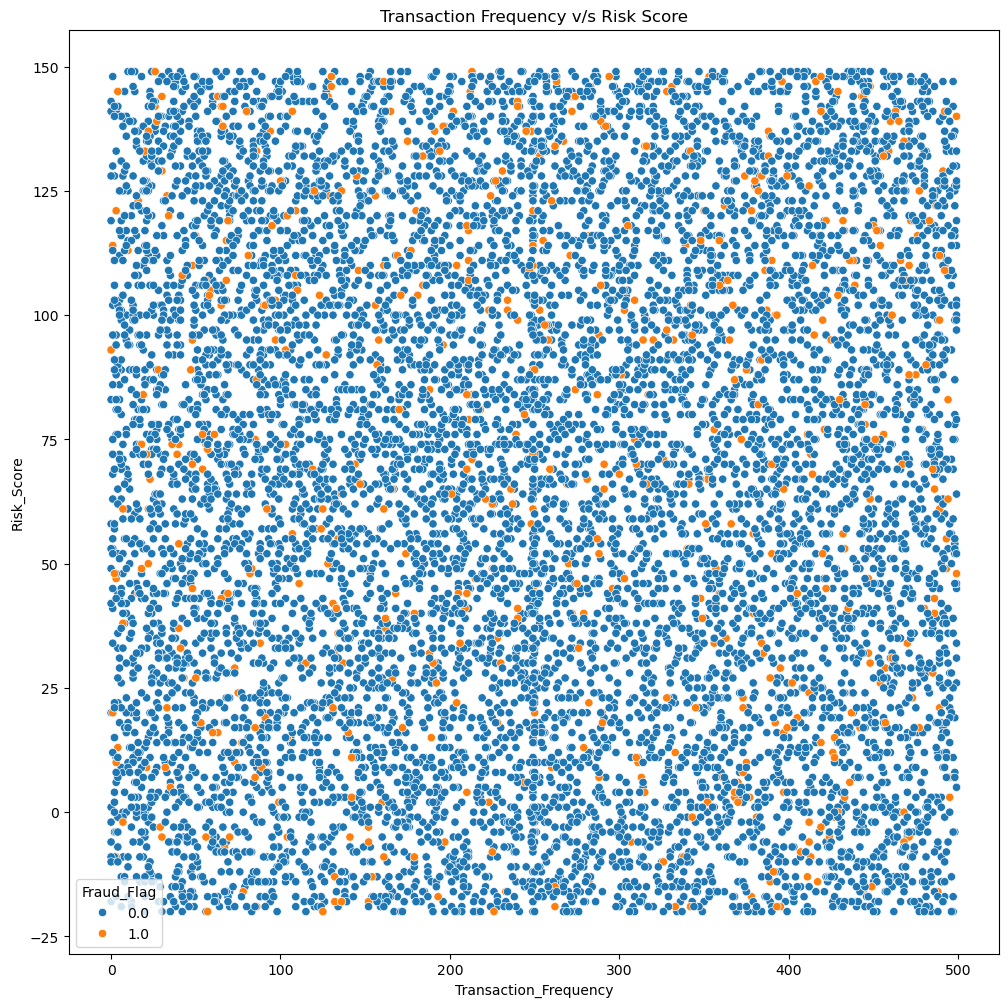

In [250]:
plt.figure(figsize=(12,12))
plt.title("Transaction Frequency v/s Risk Score")
sns.scatterplot(
    data=data.sample(10000),
    x="Transaction_Frequency",
    y="Risk_Score",
    hue="Fraud_Flag"
)
plt.show()

#### **18. Missing Values Heatmap**

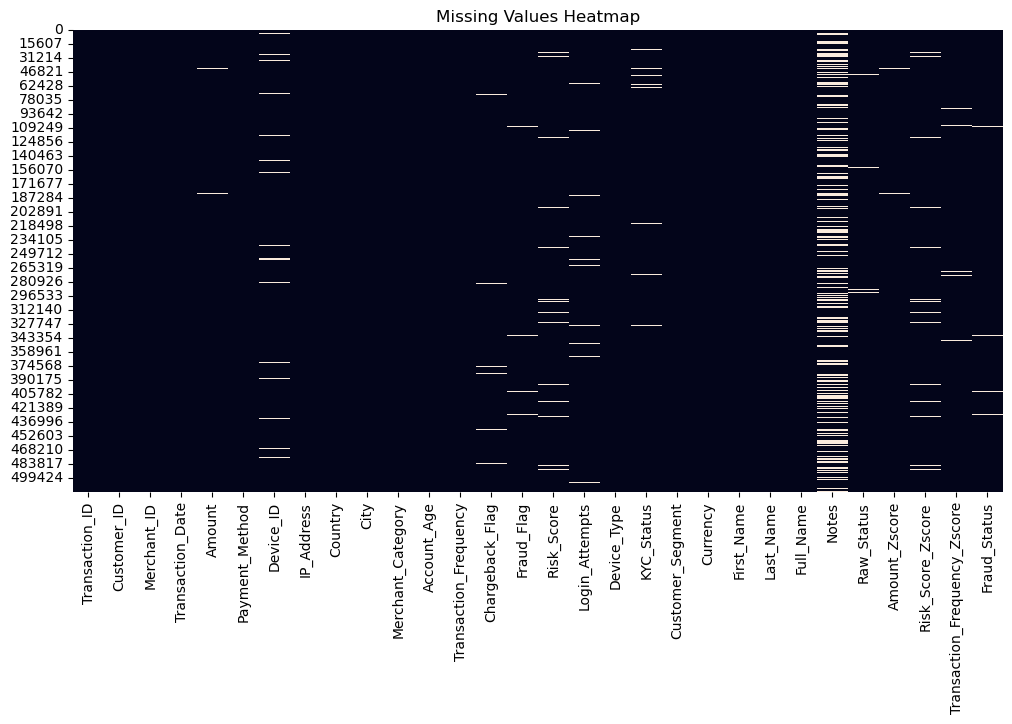

In [252]:
plt.figure(figsize=(12,6))
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

#### **19. Outlier Detection**

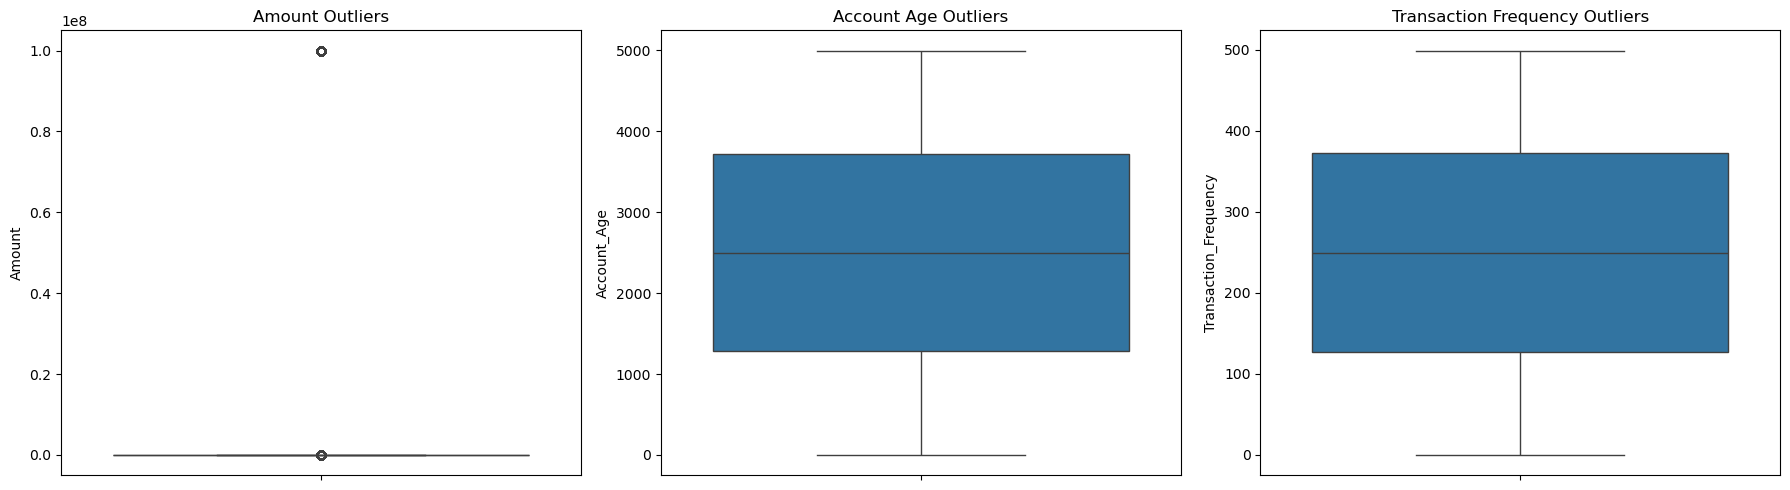

In [257]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=data, y="Amount", ax=ax[0])
ax[0].set_title("Amount Outliers")

sns.boxplot(data=data, y="Account_Age", ax=ax[1])
ax[1].set_title("Account Age Outliers")

sns.boxplot(data=data, y="Transaction_Frequency", ax=ax[2])
ax[2].set_title("Transaction Frequency Outliers")

plt.tight_layout()
plt.show()

#### **20. Fraud Rate by Risk Category**

In [261]:
data["Risk_Category"] = pd.cut(
    data["Risk_Score"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

fraud_rate = (
    data.groupby("Risk_Category")["Fraud_Flag"]
    .mean()
    .reset_index()
)

fraud_rate["Fraud_Rate"] = fraud_rate["Fraud_Flag"] * 100

fig = px.bar(
    fraud_rate,
    x="Risk_Category",
    y="Fraud_Rate",
    color="Fraud_Rate",
    category_orders={
        "Risk_Category": [
            "Very Low",
            "Low",
            "Medium",
            "High",
            "Critical"
        ]
    },
    text_auto=".2f",
    title="Fraud Rate by Risk Category (%)"
)

fig.show()

C:\Users\Krishnam Mavani\AppData\Local\Temp\ipykernel_1456\3223689092.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



#### **21. Pair Plot**

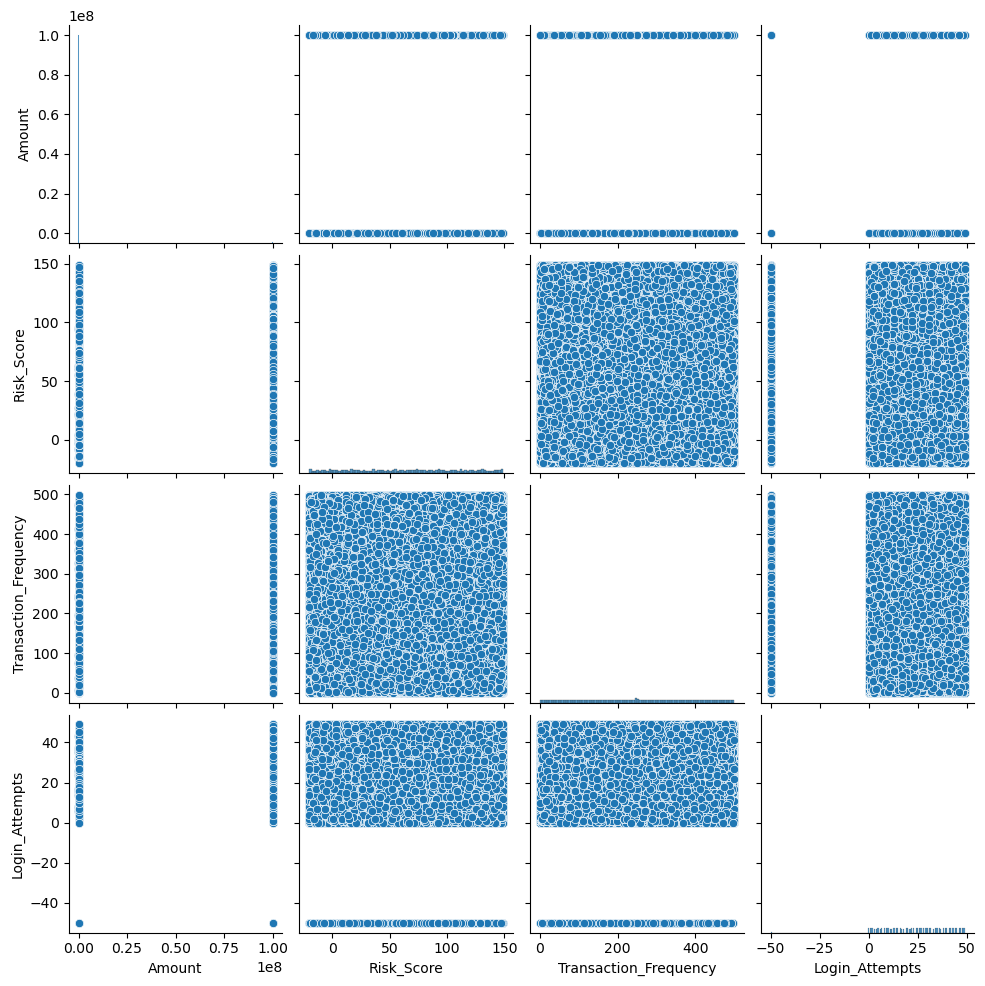

In [265]:
cols = [
    "Amount",
    "Risk_Score",
    "Transaction_Frequency",
    "Login_Attempts",
    "Fraud_Status"
]

sns.pairplot(data[cols])
plt.show()

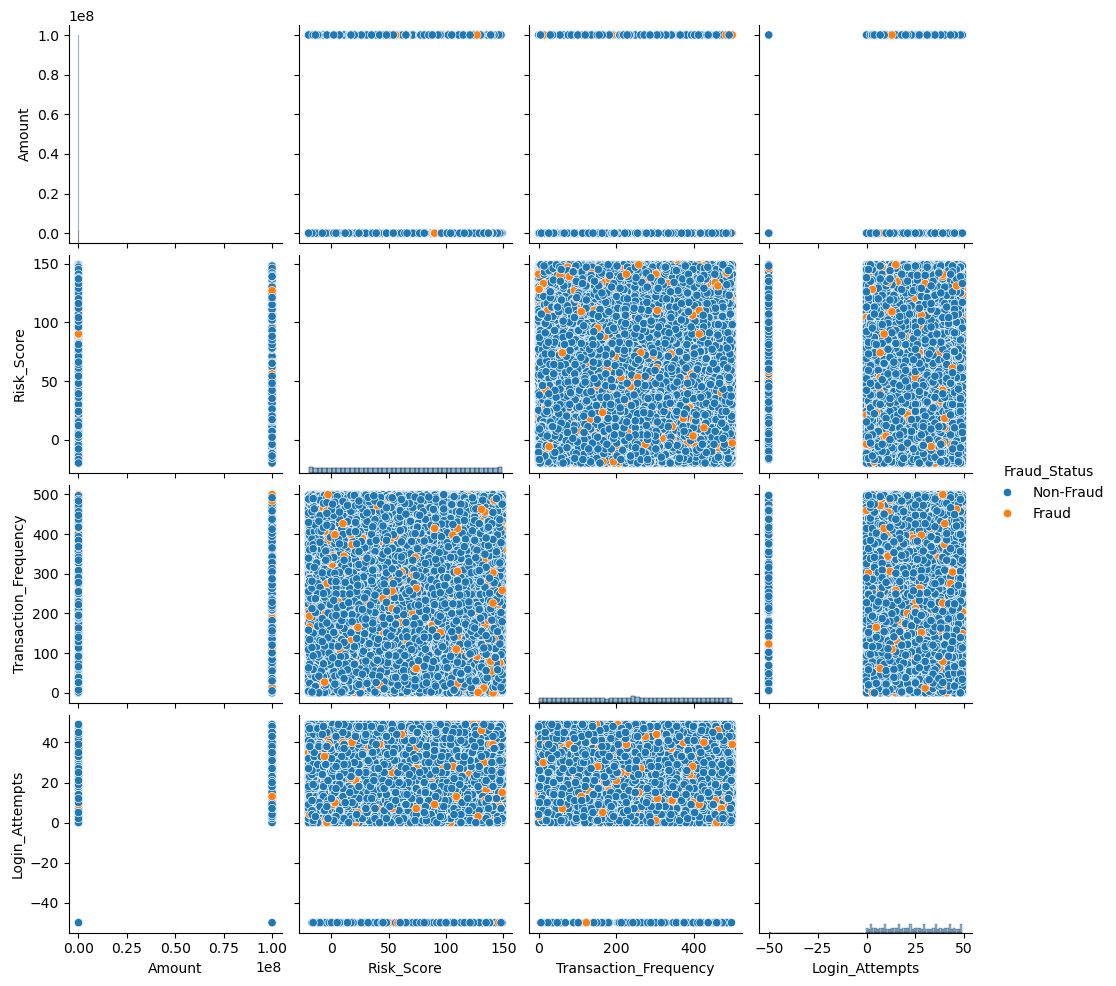

In [267]:
sample_size = int(data.shape[0] * 0.15)
sample_df = data.sample(sample_size, random_state=42)
sns.pairplot(
    sample_df[cols],
    hue="Fraud_Status",
    diag_kind="hist"
)

plt.show()